In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

In [3]:
import numpy as np
import pandas as pd

df=pd.read_csv('train.csv')
test_df=pd.read_csv('test.csv')
or_df=test_df
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4376 non-null   object 
 1   설립연도            4376 non-null   int64  
 2   국가              4376 non-null   object 
 3   분야              3519 non-null   object 
 4   투자단계            4376 non-null   object 
 5   직원 수            4202 non-null   float64
 6   인수여부            4376 non-null   object 
 7   상장여부            4376 non-null   object 
 8   고객수(백만명)        3056 non-null   float64
 9   총 투자금(억원)       4376 non-null   float64
 10  연매출(억원)         4376 non-null   float64
 11  SNS 팔로워 수(백만명)  4376 non-null   float64
 12  기업가치(백억원)       3156 non-null   object 
 13  성공확률            4376 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 478.8+ KB


,설립연도,직원 수,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),성공확률
count,4376.000000,4202.000000,3056.000000,4376.000000,4376.000000,4376.000000,4376.000000
mean,2012.006856,2471.324369,49.214332,3314.568556,6452.202239,2.578103,0.537340
std,6.554872,1446.064215,27.141242,1880.103831,3782.792656,1.414590,0.241698
min,2001.000000,5.000000,1.000000,12.000000,12.000000,0.000000,0.100000
25%,2006.000000,1218.250000,27.000000,1651.500000,3094.250000,1.320000,0.400000
50%,2012.000000,2472.000000,49.000000,3398.000000,6478.500000,2.835000,0.600000
75%,2018.000000,3727.500000,72.000000,4908.250000,9692.500000,4.000000,0.700000
max,2023.000000,4998.000000,99.000000,7059.000000,14822.000000,5.000000,0.900000


In [4]:
df.isna().sum()

ID                   0
설립연도                 0
국가                   0
분야                 857
투자단계                 0
직원 수               174
인수여부                 0
상장여부                 0
고객수(백만명)          1320
총 투자금(억원)            0
연매출(억원)              0
SNS 팔로워 수(백만명)       0
기업가치(백억원)         1220
성공확률                 0
dtype: int64

In [5]:
df.head()

,ID,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률
0,TRAIN_0000,2009,CT005,이커머스,Series A,4126.0,No,No,56.0,3365.0,4764.0,4.71,NaN,0.3
1,TRAIN_0001,2023,CT006,핀테크,Seed,4167.0,Yes,No,80.0,4069.0,279.0,1.00,2500-3500,0.8
2,TRAIN_0002,2018,CT007,기술,Series A,3132.0,Yes,Yes,54.0,6453.0,12141.0,4.00,3500-4500,0.5
3,TRAIN_0003,2016,CT006,NaN,Seed,3245.0,Yes,Yes,NaN,665.0,10547.0,2.97,NaN,0.7
4,TRAIN_0004,2020,CT002,에듀테크,Seed,1969.0,No,Yes,94.0,829.0,9810.0,1.00,1500-2500,0.1


In [6]:
df['인수여부']=df['인수여부'].map({'Yes': 1, 'No': 0}) # Yes는 1, No는 0
test_df['인수여부']=test_df['인수여부'].map({'Yes': 1, 'No': 0}) # Yes는 1, No는 0
df.head()

,ID,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률
0,TRAIN_0000,2009,CT005,이커머스,Series A,4126.0,0,No,56.0,3365.0,4764.0,4.71,NaN,0.3
1,TRAIN_0001,2023,CT006,핀테크,Seed,4167.0,1,No,80.0,4069.0,279.0,1.00,2500-3500,0.8
2,TRAIN_0002,2018,CT007,기술,Series A,3132.0,1,Yes,54.0,6453.0,12141.0,4.00,3500-4500,0.5
3,TRAIN_0003,2016,CT006,NaN,Seed,3245.0,1,Yes,NaN,665.0,10547.0,2.97,NaN,0.7
4,TRAIN_0004,2020,CT002,에듀테크,Seed,1969.0,0,Yes,94.0,829.0,9810.0,1.00,1500-2500,0.1


In [7]:
df['상장여부']=df['상장여부'].map({'Yes': 1, 'No': 0}) # Yes는 1, No는 0
test_df['상장여부']=test_df['상장여부'].map({'Yes': 1, 'No': 0})
df.head()

,ID,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률
0,TRAIN_0000,2009,CT005,이커머스,Series A,4126.0,0,0,56.0,3365.0,4764.0,4.71,NaN,0.3
1,TRAIN_0001,2023,CT006,핀테크,Seed,4167.0,1,0,80.0,4069.0,279.0,1.00,2500-3500,0.8
2,TRAIN_0002,2018,CT007,기술,Series A,3132.0,1,1,54.0,6453.0,12141.0,4.00,3500-4500,0.5
3,TRAIN_0003,2016,CT006,NaN,Seed,3245.0,1,1,NaN,665.0,10547.0,2.97,NaN,0.7
4,TRAIN_0004,2020,CT002,에듀테크,Seed,1969.0,0,1,94.0,829.0,9810.0,1.00,1500-2500,0.1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4376 non-null   object 
 1   설립연도            4376 non-null   int64  
 2   국가              4376 non-null   object 
 3   분야              3519 non-null   object 
 4   투자단계            4376 non-null   object 
 5   직원 수            4202 non-null   float64
 6   인수여부            4376 non-null   int64  
 7   상장여부            4376 non-null   int64  
 8   고객수(백만명)        3056 non-null   float64
 9   총 투자금(억원)       4376 non-null   float64
 10  연매출(억원)         4376 non-null   float64
 11  SNS 팔로워 수(백만명)  4376 non-null   float64
 12  기업가치(백억원)       3156 non-null   object 
 13  성공확률            4376 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 478.8+ KB


In [9]:
df['분야'].describe()

count     3519
unique      10
top        에너지
freq       396
Name: 분야, dtype: object

In [10]:
df['분야']=df['분야'].fillna('기타') # 결측값은 기타로 채운다
test_df['분야']=test_df['분야'].fillna('기타')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4376 non-null   object 
 1   설립연도            4376 non-null   int64  
 2   국가              4376 non-null   object 
 3   분야              4376 non-null   object 
 4   투자단계            4376 non-null   object 
 5   직원 수            4202 non-null   float64
 6   인수여부            4376 non-null   int64  
 7   상장여부            4376 non-null   int64  
 8   고객수(백만명)        3056 non-null   float64
 9   총 투자금(억원)       4376 non-null   float64
 10  연매출(억원)         4376 non-null   float64
 11  SNS 팔로워 수(백만명)  4376 non-null   float64
 12  기업가치(백억원)       3156 non-null   object 
 13  성공확률            4376 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 478.8+ KB


In [11]:
df['직원 수'].describe()

count    4202.000000
mean     2471.324369
std      1446.064215
min         5.000000
25%      1218.250000
50%      2472.000000
75%      3727.500000
max      4998.000000
Name: 직원 수, dtype: float64

In [12]:
df.groupby('분야')['직원 수'].describe()

,count,mean,std,min,25%,50%,75%,max
분야,,,,,,,,
AI,356.0,2566.500000,1416.433127,49.0,1434.00,2596.5,3714.50,4981.0
게임,359.0,2526.270195,1449.990436,7.0,1334.00,2557.0,3708.50,4997.0
기술,389.0,2595.529563,1472.553539,5.0,1265.00,2717.0,3930.00,4961.0
기타,683.0,2461.606149,1471.671301,12.0,1206.50,2504.0,3765.00,4984.0
물류,328.0,2478.329268,1396.865066,11.0,1251.25,2468.5,3657.75,4959.0
에너지,396.0,2479.888889,1380.278217,37.0,1315.75,2420.5,3634.75,4920.0
에듀테크,364.0,2299.329670,1446.481772,5.0,970.25,2193.0,3510.00,4978.0
이커머스,332.0,2494.740964,1426.118595,35.0,1421.75,2472.5,3793.00,4994.0
푸드테크,335.0,2545.074627,1535.127500,19.0,1143.50,2694.0,3877.50,4998.0


In [13]:
reg_df = df
reg_test_df = test_df

In [14]:
from sklearn.linear_model import LinearRegression

#train = reg_df[reg_df['직원 수'].notna()] # 결측값 없는 행 -> 학습
#test = reg_df[reg_df['직원 수'].isna()] # 결측값 행 -> 예측

#features = ['총 투자금(억원)'] # 활용할 변수
#X_train = train[features]
#y_train = train['직원 수']
#X_test = test[features]

#model = LinearRegression() # 선형 회귀
#model.fit(X_train, y_train)
#preds = model.predict(X_test)

#reg_df.loc[reg_df['직원 수'].isna(), '직원 수'] = preds

In [15]:
df['직원 수']=df['직원 수'].fillna(df['직원 수'].mean())
test_df['직원 수']=test_df['직원 수'].fillna(test_df['직원 수'].mean())

In [16]:
#train = reg_test_df[reg_test_df['직원 수'].notna()] # 결측값 없는 행 -> 학습
#test = reg_test_df[reg_test_df['직원 수'].isna()] # 결측값 행 -> 예측

#features = ['총 투자금(억원)'] # 활용할 변수
#X_train = train[features]
#y_train = train['직원 수']
#X_test = test[features]

#test_model=LinearRegression()
#test_model.fit(X_train, y_train)
#preds=test_model.predict(X_test)
#reg_test_df.loc[reg_test_df['직원 수'].isna(), '직원 수'] = preds

In [17]:
df.groupby('분야')['직원 수'].describe()

,count,mean,std,min,25%,50%,75%,max
분야,,,,,,,,
AI,356.0,2566.500000,1416.433127,49.0,1434.00,2596.500000,3714.50,4981.0
게임,359.0,2526.270195,1449.990436,7.0,1334.00,2557.000000,3708.50,4997.0
기술,389.0,2595.529563,1472.553539,5.0,1265.00,2717.000000,3930.00,4961.0
기타,857.0,2463.579277,1313.614855,12.0,1418.00,2471.324369,3379.00,4984.0
물류,328.0,2478.329268,1396.865066,11.0,1251.25,2468.500000,3657.75,4959.0
에너지,396.0,2479.888889,1380.278217,37.0,1315.75,2420.500000,3634.75,4920.0
에듀테크,364.0,2299.329670,1446.481772,5.0,970.25,2193.000000,3510.00,4978.0
이커머스,332.0,2494.740964,1426.118595,35.0,1421.75,2472.500000,3793.00,4994.0
푸드테크,335.0,2545.074627,1535.127500,19.0,1143.50,2694.000000,3877.50,4998.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4376 non-null   object 
 1   설립연도            4376 non-null   int64  
 2   국가              4376 non-null   object 
 3   분야              4376 non-null   object 
 4   투자단계            4376 non-null   object 
 5   직원 수            4376 non-null   float64
 6   인수여부            4376 non-null   int64  
 7   상장여부            4376 non-null   int64  
 8   고객수(백만명)        3056 non-null   float64
 9   총 투자금(억원)       4376 non-null   float64
 10  연매출(억원)         4376 non-null   float64
 11  SNS 팔로워 수(백만명)  4376 non-null   float64
 12  기업가치(백억원)       3156 non-null   object 
 13  성공확률            4376 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 478.8+ KB


In [19]:
df=pd.get_dummies(df, columns=['분야']) #원 핫 인코딩
test_df=pd.get_dummies(test_df, columns=['분야'])
#reg_df=pd.get_dummies(reg_df, columns=['분야']) #원 핫 인코딩
#reg_test_df=pd.get_dummies(reg_test_df, columns=['분야'])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4376 non-null   object 
 1   설립연도            4376 non-null   int64  
 2   국가              4376 non-null   object 
 3   투자단계            4376 non-null   object 
 4   직원 수            4376 non-null   float64
 5   인수여부            4376 non-null   int64  
 6   상장여부            4376 non-null   int64  
 7   고객수(백만명)        3056 non-null   float64
 8   총 투자금(억원)       4376 non-null   float64
 9   연매출(억원)         4376 non-null   float64
 10  SNS 팔로워 수(백만명)  4376 non-null   float64
 11  기업가치(백억원)       3156 non-null   object 
 12  성공확률            4376 non-null   float64
 13  분야_AI           4376 non-null   bool   
 14  분야_게임           4376 non-null   bool   
 15  분야_기술           4376 non-null   bool   
 16  분야_기타           4376 non-null   bool   
 17  분야_물류           4376 non-null   b

In [21]:
#train = reg_df[reg_df['고객수(백만명)'].notna()] # 결측값 없는 행 -> 학습
#test = reg_df[reg_df['고객수(백만명)'].isna()] # 결측값 행 -> 예측

#features = ['연매출(억원)'] # 활용할 변수
#X_train = train[features]
#y_train = train['고객수(백만명)']
#X_test = test[features]

#model = LinearRegression() # 선형 회귀
#model.fit(X_train, y_train)
#preds = model.predict(X_test)

#reg_df.loc[reg_df['고객수(백만명)'].isna(), '고객수(백만명)'] = preds

In [22]:
#train = reg_test_df[reg_test_df['고객수(백만명)'].notna()] # 결측값 없는 행 -> 학습
#test = reg_test_df[reg_test_df['고객수(백만명)'].isna()] # 결측값 행 -> 예측

#features = ['연매출(억원)'] # 활용할 변수
#X_train = train[features]
#y_train = train['고객수(백만명)']
#X_test = test[features]

#test_model=LinearRegression()
#test_model.fit(X_train, y_train)
#preds=test_model.predict(X_test)
#reg_test_df.loc[reg_test_df['고객수(백만명)'].isna(), '고객수(백만명)'] = preds

In [23]:
df['고객수(백만명)']=df.groupby('국가')['고객수(백만명)'].transform(lambda x : x.fillna(x.median()))
test_df['고객수(백만명)']=test_df.groupby('국가')['고객수(백만명)'].transform(lambda x : x.fillna(x.median()))

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4376 non-null   object 
 1   설립연도            4376 non-null   int64  
 2   국가              4376 non-null   object 
 3   투자단계            4376 non-null   object 
 4   직원 수            4376 non-null   float64
 5   인수여부            4376 non-null   int64  
 6   상장여부            4376 non-null   int64  
 7   고객수(백만명)        4376 non-null   float64
 8   총 투자금(억원)       4376 non-null   float64
 9   연매출(억원)         4376 non-null   float64
 10  SNS 팔로워 수(백만명)  4376 non-null   float64
 11  기업가치(백억원)       3156 non-null   object 
 12  성공확률            4376 non-null   float64
 13  분야_AI           4376 non-null   bool   
 14  분야_게임           4376 non-null   bool   
 15  분야_기술           4376 non-null   bool   
 16  분야_기타           4376 non-null   bool   
 17  분야_물류           4376 non-null   b

In [25]:
df.head()

,ID,설립연도,국가,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),...,분야_게임,분야_기술,분야_기타,분야_물류,분야_에너지,분야_에듀테크,분야_이커머스,분야_푸드테크,분야_핀테크,분야_헬스케어
0,TRAIN_0000,2009,CT005,Series A,4126.0,0,0,56.0,3365.0,4764.0,...,False,False,False,False,False,False,True,False,False,False
1,TRAIN_0001,2023,CT006,Seed,4167.0,1,0,80.0,4069.0,279.0,...,False,False,False,False,False,False,False,False,True,False
2,TRAIN_0002,2018,CT007,Series A,3132.0,1,1,54.0,6453.0,12141.0,...,False,True,False,False,False,False,False,False,False,False
3,TRAIN_0003,2016,CT006,Seed,3245.0,1,1,46.0,665.0,10547.0,...,False,False,True,False,False,False,False,False,False,False
4,TRAIN_0004,2020,CT002,Seed,1969.0,0,1,94.0,829.0,9810.0,...,False,False,False,False,False,True,False,False,False,False


In [26]:
# 평균값을 반환하는 함수, 결측값은 그대로 결측값, 6000 이상은 6000으로 반환
def mean_value(x):
    if pd.isna(x):
        return np.nan
    parts = x.split('-')
    if len(parts) == 2:
        start, end = x.split('-')
        return (int(start) + int(end)) / 2
    else:
        return 6000

df['기업가치(백억원)']=df['기업가치(백억원)'].apply(mean_value) # 함수 적용
test_df['기업가치(백억원)']=test_df['기업가치(백억원)'].apply(mean_value)
#reg_df['기업가치(백억원)']=reg_df['기업가치(백억원)'].apply(mean_value)
#reg_test_df['기업가치(백억원)']=reg_test_df['기업가치(백억원)'].apply(mean_value)

In [27]:
#train = reg_df[reg_df['기업가치(백억원)'].notna()] # 결측값 없는 행 -> 학습
#test = reg_df[reg_df['기업가치(백억원)'].isna()] # 결측값 행 -> 예측

#features = ['연매출(억원)'] # 활용할 변수
#X_train = train[features]
#y_train = train['기업가치(백억원)']
#X_test = test[features]

#model = LinearRegression()
#model.fit(X_train, y_train)
#preds = model.predict(X_test)

#reg_df.loc[reg_df['기업가치(백억원)'].isna(), '기업가치(백억원)'] = preds

In [28]:
#train = reg_test_df[reg_test_df['기업가치(백억원)'].notna()] # 결측값 없는 행 -> 학습
#test = reg_test_df[reg_test_df['기업가치(백억원)'].isna()] # 결측값 행 -> 예측

#features = ['연매출(억원)'] # 활용할 변수
#X_train = train[features]
#y_train = train['기업가치(백억원)']
#X_test = test[features]

#test_model=LinearRegression()
#test_model.fit(X_train, y_train)
#preds=test_model.predict(X_test)
#reg_test_df.loc[reg_test_df['기업가치(백억원)'].isna(), '기업가치(백억원)'] = preds

In [29]:
df['기업가치(백억원)']=df['기업가치(백억원)'].fillna(df['기업가치(백억원)'].mean())
test_df['기업가치(백억원)']=test_df['기업가치(백억원)'].fillna(test_df['기업가치(백억원)'].mean())

In [30]:
df['기업가치(백억원)'].head(100)

0     4049.984157
1     3000.000000
2     4000.000000
3     4049.984157
4     2000.000000
         ...     
95    4000.000000
96    2000.000000
97    6000.000000
98    2000.000000
99    3000.000000
Name: 기업가치(백억원), Length: 100, dtype: float64

In [31]:
df.head(10)

,ID,설립연도,국가,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),...,분야_게임,분야_기술,분야_기타,분야_물류,분야_에너지,분야_에듀테크,분야_이커머스,분야_푸드테크,분야_핀테크,분야_헬스케어
0,TRAIN_0000,2009,CT005,Series A,4126.000000,0,0,56.0,3365.0,4764.0,...,False,False,False,False,False,False,True,False,False,False
1,TRAIN_0001,2023,CT006,Seed,4167.000000,1,0,80.0,4069.0,279.0,...,False,False,False,False,False,False,False,False,True,False
2,TRAIN_0002,2018,CT007,Series A,3132.000000,1,1,54.0,6453.0,12141.0,...,False,True,False,False,False,False,False,False,False,False
3,TRAIN_0003,2016,CT006,Seed,3245.000000,1,1,46.0,665.0,10547.0,...,False,False,True,False,False,False,False,False,False,False
4,TRAIN_0004,2020,CT002,Seed,1969.000000,0,1,94.0,829.0,9810.0,...,False,False,False,False,False,True,False,False,False,False
5,TRAIN_0005,2012,CT008,Series C,3801.000000,0,1,69.0,6505.0,12722.0,...,False,True,False,False,False,False,False,False,False,False
6,TRAIN_0006,2008,CT010,Series B,818.000000,0,1,53.0,3049.0,666.0,...,False,False,True,False,False,False,False,False,False,False
7,TRAIN_0007,2020,CT002,Series A,2617.000000,0,0,80.0,5579.0,5399.0,...,True,False,False,False,False,False,False,False,False,False
8,TRAIN_0008,2005,CT002,Series B,2471.324369,0,0,47.0,2722.0,2568.0,...,False,False,True,False,False,False,False,False,False,False
9,TRAIN_0009,2009,CT008,Series B,1757.000000,0,0,48.0,285.0,11758.0,...,False,False,True,False,False,False,False,False,False,False


In [32]:
df=df.drop(columns=['ID', '설립연도', '국가'], axis=1)
test_df=test_df.drop(columns=['ID', '설립연도', '국가'], axis=1)
#reg_df=reg_df.drop(columns=['ID', '설립연도', '국가'], axis=1)
#reg_test_df=reg_test_df.drop(columns=['ID', '설립연도', '국가'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   투자단계            4376 non-null   object 
 1   직원 수            4376 non-null   float64
 2   인수여부            4376 non-null   int64  
 3   상장여부            4376 non-null   int64  
 4   고객수(백만명)        4376 non-null   float64
 5   총 투자금(억원)       4376 non-null   float64
 6   연매출(억원)         4376 non-null   float64
 7   SNS 팔로워 수(백만명)  4376 non-null   float64
 8   기업가치(백억원)       4376 non-null   float64
 9   성공확률            4376 non-null   float64
 10  분야_AI           4376 non-null   bool   
 11  분야_게임           4376 non-null   bool   
 12  분야_기술           4376 non-null   bool   
 13  분야_기타           4376 non-null   bool   
 14  분야_물류           4376 non-null   bool   
 15  분야_에너지          4376 non-null   bool   
 16  분야_에듀테크         4376 non-null   bool   
 17  분야_이커머스         4376 non-null   b

In [33]:
df['투자단계'].describe()

count     4376
unique       5
top        IPO
freq       938
Name: 투자단계, dtype: object

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   투자단계            4376 non-null   object 
 1   직원 수            4376 non-null   float64
 2   인수여부            4376 non-null   int64  
 3   상장여부            4376 non-null   int64  
 4   고객수(백만명)        4376 non-null   float64
 5   총 투자금(억원)       4376 non-null   float64
 6   연매출(억원)         4376 non-null   float64
 7   SNS 팔로워 수(백만명)  4376 non-null   float64
 8   기업가치(백억원)       4376 non-null   float64
 9   성공확률            4376 non-null   float64
 10  분야_AI           4376 non-null   bool   
 11  분야_게임           4376 non-null   bool   
 12  분야_기술           4376 non-null   bool   
 13  분야_기타           4376 non-null   bool   
 14  분야_물류           4376 non-null   bool   
 15  분야_에너지          4376 non-null   bool   
 16  분야_에듀테크         4376 non-null   bool   
 17  분야_이커머스         4376 non-null   b

In [35]:
df.describe()

,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률
count,4376.000000,4376.000000,4376.000000,4376.000000,4376.000000,4376.000000,4376.000000,4376.000000,4376.000000
mean,2471.324369,0.515768,0.482861,49.050274,3314.568556,6452.202239,2.578103,4049.984157,0.537340
std,1417.016447,0.499808,0.499763,22.736156,1880.103831,3782.792656,1.414590,1223.022252,0.241698
min,5.000000,0.000000,0.000000,1.000000,12.000000,12.000000,0.000000,2000.000000,0.100000
25%,1272.000000,0.000000,0.000000,37.000000,1651.500000,3094.250000,1.320000,3000.000000,0.400000
50%,2471.324369,1.000000,0.000000,48.000000,3398.000000,6478.500000,2.835000,4049.984157,0.600000
75%,3675.250000,1.000000,1.000000,62.000000,4908.250000,9692.500000,4.000000,5250.000000,0.700000
max,4998.000000,1.000000,1.000000,99.000000,7059.000000,14822.000000,5.000000,6000.000000,0.900000


In [36]:
from sklearn.preprocessing import OrdinalEncoder
#ordinal encoding -> 투자  단계별로 순서(등급)가 있기 때문에 사용
order = ['Seed', 'Series A', 'Series B', 'Series C', 'IPO']

enc = OrdinalEncoder(categories=[order])
df['투자단계'] = enc.fit_transform(df[['투자단계']])
test_df['투자단계'] = enc.fit_transform(test_df[['투자단계']])
#reg_df['투자단계'] = enc.fit_transform(reg_df[['투자단계']])
#reg_test_df['투자단계'] = enc.fit_transform(reg_test_df[['투자단계']])

In [37]:
df.head(10)

,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률,...,분야_게임,분야_기술,분야_기타,분야_물류,분야_에너지,분야_에듀테크,분야_이커머스,분야_푸드테크,분야_핀테크,분야_헬스케어
0,1.0,4126.000000,0,0,56.0,3365.0,4764.0,4.71,4049.984157,0.3,...,False,False,False,False,False,False,True,False,False,False
1,0.0,4167.000000,1,0,80.0,4069.0,279.0,1.00,3000.000000,0.8,...,False,False,False,False,False,False,False,False,True,False
2,1.0,3132.000000,1,1,54.0,6453.0,12141.0,4.00,4000.000000,0.5,...,False,True,False,False,False,False,False,False,False,False
3,0.0,3245.000000,1,1,46.0,665.0,10547.0,2.97,4049.984157,0.7,...,False,False,True,False,False,False,False,False,False,False
4,0.0,1969.000000,0,1,94.0,829.0,9810.0,1.00,2000.000000,0.1,...,False,False,False,False,False,True,False,False,False,False
5,3.0,3801.000000,0,1,69.0,6505.0,12722.0,3.00,3000.000000,0.6,...,False,True,False,False,False,False,False,False,False,False
6,2.0,818.000000,0,1,53.0,3049.0,666.0,0.76,3000.000000,0.4,...,False,False,True,False,False,False,False,False,False,False
7,1.0,2617.000000,0,0,80.0,5579.0,5399.0,4.00,4000.000000,0.7,...,True,False,False,False,False,False,False,False,False,False
8,2.0,2471.324369,0,0,47.0,2722.0,2568.0,4.94,4049.984157,0.9,...,False,False,True,False,False,False,False,False,False,False
9,2.0,1757.000000,0,0,48.0,285.0,11758.0,2.33,4049.984157,0.5,...,False,False,True,False,False,False,False,False,False,False


## XGB를 이용한 예측 모델

In [39]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['성공확률'])
y = df['성공확률']
#X_reg = reg_df.drop(columns=['성공확률'])
#y_reg = reg_df['성공확률']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

import seaborn as sns
#sns.kdeplot(y_train, label='Train')
#sns.kdeplot(y_test, label='Test')

# 값이 큰 컬럼은 정규화
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
test_df_scaled = scaler.transform(test_df)

XGB_model=XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
XGB_model.fit(X_train, y_train)

y_pred = XGB_model.predict(X_test)
print(r2_score(y_test, y_pred))

#XGB_model.fit(X_reg_train, y_reg_train)
#y_reg_pred = XGB_model.predict(X_reg_test)
#print(r2_score(y_reg_test, y_reg_pred))

-0.06327865217668593


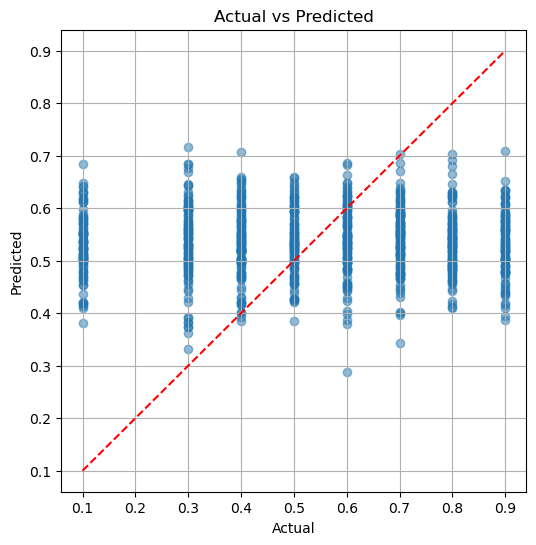

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA

RF_model = RandomForestRegressor() # random forest
RF_model.fit(X_train_scaled, y_train)

y_pred=RF_model.predict(X_test_scaled)

pca = PCA(n_components=0.95) # 차원 축소 버전
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
test_df_pca = pca.transform(test_df)

RF_model_pca = RandomForestRegressor() # 차원 축소에 맞춘 RF
RF_model_pca.fit(X_train_pca, y_train)
y_pred_pca = RF_model_pca.predict(X_test_pca)

In [42]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred_pca))
print("MSE:", mean_squared_error(y_test, y_pred_pca))

MAE: 0.20179794520547945
MSE: 0.05926463584474885
MAE: 0.19404337899543375
MSE: 0.0570788105022831


In [43]:
print(r2_score(y_test, y_pred_pca))

0.012395770165366304


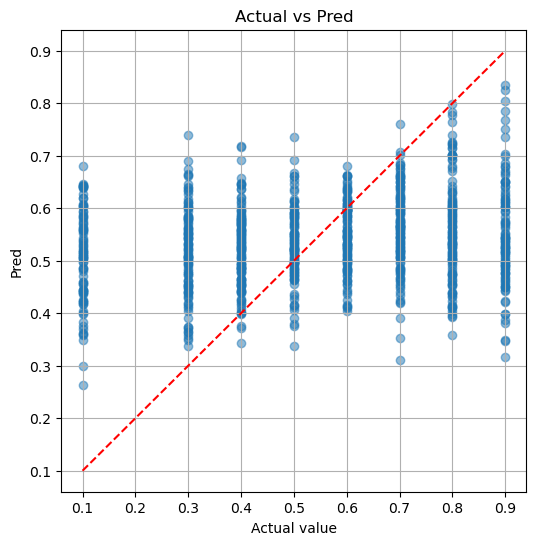

In [44]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_pca, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual value")
plt.ylabel("Pred")
plt.title("Actual vs Pred")
plt.grid(True)
plt.show()

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 성공 확률을 정수로 저장
#y_train_int = (y_train * 10).astype(int)
#y_test_int = (y_test * 10).astype(int)

# 로지스틱 회귀 활용
LG_model = LogisticRegression(max_iter=200)
LG_model.fit(X_train_scaled, y_train_int)

y_pred = LG_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test_int, y_pred))
print(r2_score(y_test_int, y_pred))

NameError: name 'y_train_int' is not defined

In [ ]:
test=RF_model_pca.predict(test_df_pca)

In [ ]:
result = pd.DataFrame({'ID': or_df['ID'], '성공확률': test})

result.to_csv("result.csv", index=False)